# Single impurities in infinite systems

A single point defect embedded in an otherwise infinite, periodic system cannot be handled by a
plain supercell without artificially periodizing the defect. `embedding.Embedding` solves this with
a Green's function embedding technique: given the pristine, periodic Hamiltonian `h` and a modified
intracell matrix describing the defect, it gives direct access to observables of the infinite system
as perturbed by that single, non-periodic impurity -- e.g. the Friedel oscillations in the LDOS
around a repulsive onsite defect on an otherwise clean chain.

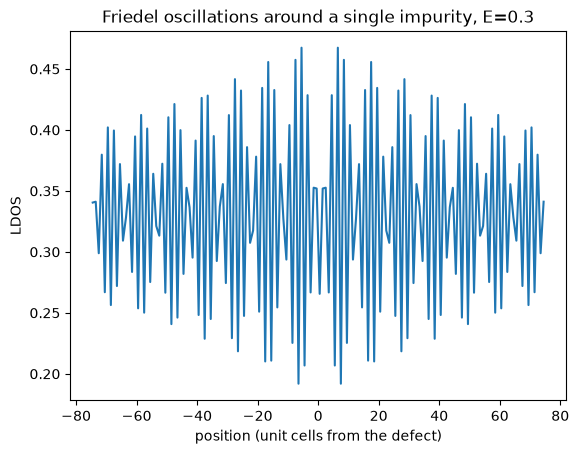

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import embedding

g = geometry.chain()
h = g.get_hamiltonian() # pristine, infinite Hamiltonian
hv = h.copy()
hv.add_onsite(lambda r: 1.0 if r[0]<0.01 else 0.0) # a single-site onsite defect
eb = embedding.Embedding(h,m=hv)

(x,y,d) = eb.get_ldos(energy=0.3,delta=1e-2,nsuper=150,nk=800,write=False)

plt.plot(x,d)
plt.xlabel("position (unit cells from the defect)") ; plt.ylabel("LDOS")
plt.title("Friedel oscillations around a single impurity, E=0.3")
plt.show()